In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_path = "trace_summary_combined.csv"

short_think_names = {
    'claude-sonnet-4-20250514-t1.0': 'CL-4',
    'claude-sonnet-4-20250514-t0.0': 'CL-4',
    'deepseek-r1-distill-llama-70b-t1.0':'LM-70B',
    'gpt-oss-120b-t1.0':'GPT-OSS',
    'nemotron-nano-9b-v2-t1.0':'Nem-9B',
    'qwen3-next-80b-a3b-thinking-t1.0':'Qwen-3'
}

def shorten_model_names(df):
    df['model'] = df['model'].map(short_think_names)
    return df

df = pd.read_csv(df_path)
trace_df = shorten_model_names(df)
# Make percentages out of author_role
trace_df['author_role'] = trace_df['author_role'] * 100
trace_df.head()

,game_language,model,game,experiment,instance,author_role,agentive_persons,user_mentioned,player_count,loops,...,suspects_deception,intends_deception,main_score,response_rate,aborted,lose,success,thinking_length,response_length,ratio_thinking_response
0,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_hard,4,100.0,1.0,0.0,2.0,0.0,...,0.0,0.2,0.0,1.0,1,0,0,37880,1889,0.049868
1,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_hard,5,100.0,1.6,0.0,2.0,0.2,...,0.0,0.0,0.0,1.0,1,0,0,32160,715,0.022233
2,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_easy,4,100.0,1.0,0.6,2.0,0.2,...,0.0,0.0,0.0,1.0,1,0,0,30715,1607,0.052320
3,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_easy,5,100.0,0.8,0.6,1.8,0.2,...,0.0,0.0,0.0,1.0,1,0,0,32246,1053,0.032655
4,en,LM-70B,hot_air_balloon,air_balloon_survival_en_complexity_hard,3,40.0,1.6,0.6,2.0,0.2,...,0.0,0.2,0.0,1.0,1,0,0,14289,2410,0.168661


In [24]:
# print column names
print(trace_df.columns)

Index(['game_language', 'model', 'game', 'experiment', 'instance',
       'author_role', 'agentive_persons', 'user_mentioned', 'player_count',
       'loops', 'frustration', 'confusion', 'excitement',
       'trace_language_count', 'suspects_deception', 'intends_deception',
       'main_score', 'response_rate', 'aborted', 'lose', 'success',
       'thinking_length', 'response_length', 'ratio_thinking_response'],
      dtype='object')


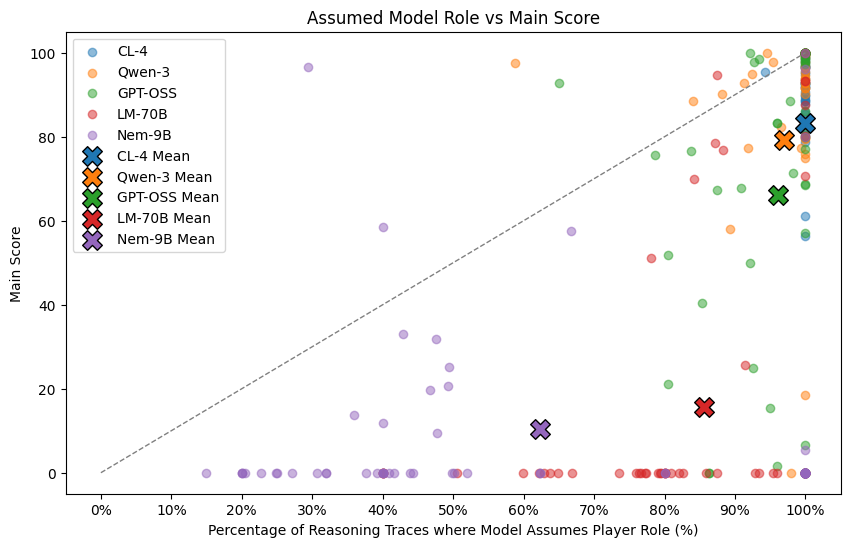

In [23]:
models = trace_df['model'].unique()

# Sort models by average main_score descending
model_means = trace_df.groupby('model')['main_score'].mean().sort_values(ascending=False)
models = model_means.index.tolist()

# plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(figsize=(10, 6))
# scatter plot with different colors for each model
# x-axis: author_role, y-axis: main_score
# Overlay two scatter plots: one for individual points, one for averages. Use same color for both.
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    ax.scatter(model_df['author_role'], model_df['main_score'], label=model, alpha=0.5, color=color)
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    main_score_mean = model_df['main_score'].mean()
    author_role_mean = model_df['author_role'].mean()
    ax.scatter(author_role_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', color=color, marker='X')

# make a diagonal line from main_score = 0, author_role = 0 to main_score = 100, author_role = 100
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1)

# make x ticks percentages
ax.set_xticks(np.arange(0, 101, 10))
# make x tick labels percentages
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_xlabel('Percentage of Reasoning Traces where Model Assumes Player Role (%)')
ax.set_ylabel('Main Score')
ax.set_title('Assumed Model Role vs Main Score')
ax.legend()
plt.savefig('author_role_vs_main_score_all_games.pdf', format='pdf')
plt.show()

In [17]:
# find out how many points are above the diagonal line and how many are below
above_total = 0
below_total = 0
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    above = ((model_df['author_role'] < model_df['main_score']).sum())
    below = ((model_df['author_role'] >= model_df['main_score']).sum())
    total = above + below
    print(f'{model}: {above} above, {below} below, {above/total:.2%} above')
    above_total += above
    below_total += below
total = above_total + below_total
print(f'Overall: {above_total}/{total} above, {below_total} below, {above_total/total:.2%} above')

CL-4: 1 above, 62 below, 1.59% above
Qwen-3: 7 above, 53 below, 11.67% above
GPT-OSS: 4 above, 55 below, 6.78% above
LM-70B: 1 above, 63 below, 1.56% above
Nem-9B: 2 above, 61 below, 3.17% above
Overall: 15/309 above, 294 below, 4.85% above


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# scatter plot with different colors for each model
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    ax.scatter(model_df['loops'], model_df['main_score'], label=model, color=plt.cm.tab10(i), alpha=0.5)
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    main_score_mean = model_df['main_score'].mean()
    loops_mean = model_df['loops'].mean()
    ax.scatter(loops_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', marker='X', color=plt.cm.tab10(i))
ax.set_xlabel('Number of Loops')
ax.set_ylabel('Main Score')
ax.set_title('Number of Loops vs Main Score')
ax.legend()
plt.savefig('loops_vs_main_score_all_games.pdf', format='pdf')
plt.show()